In [1]:
import optgraphstate as ogs
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from optimization_script import run_optimization
import stim
import igraph as ig
import scipy.io
from optgraphstate import GraphState

In [2]:
# Load functions you will use for the DP ordering

# --- Define Egde reduction function ---
def edge_reduction_func(input_graph):
    our_graph_original = input_graph.copy()
    # Create a mapping dictionary: (0, 0) -> 0, (0, 1) -> 1, ..., (2, 2) -> 8
    mapping = {node: i for i, node in enumerate(our_graph_original.nodes())}

    # Create a new graph with integer labels
    our_graph = nx.relabel_nodes(our_graph_original, mapping)
    graph , circ, statistics = run_optimization(our_graph, edge_reduction=True, minLA=False, opt_CNOT= False)
    return graph


In [3]:
#Load the functions for linear rank width 
from rank_width import linear_rank_width, lrw_of_ordering

In [5]:
# Load the functions for linear rank width SA
from rank_width_sa import linear_rank_width_sa

In [6]:
# Load the functions for path_clustering
from path_clustering import path_clustering_lrw

In [4]:
# File saving and loading functions
def save_simulation_results(data, simulation_name, data_type, base_path='/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data'):
    """
    Save simulation results to a text file.
    
    Args:
        data: List or array of numerical data to save
        simulation_name: Name of the simulation (e.g., 'SAminLA20', 'DP_edge_red')
        data_type: Type of data ('emitters' or 'cnots')
        base_path: Directory where files will be saved
    """
    filename = f'{base_path}/repeater_graph_{data_type}_{simulation_name}.txt'
    np.savetxt(filename, data, fmt='%d')
    print(f"Saved {data_type} data to: {filename}")
    
def load_simulation_results(simulation_name, data_type, base_path='/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data'):
    """
    Load simulation results from a text file.
    
    Args:
        simulation_name: Name of the simulation (e.g., 'SAminLA20', 'DP_edge_red')
        data_type: Type of data ('emitters' or 'cnots')
        base_path: Directory where files are stored
        
    Returns:
        Numpy array with the loaded data
    """
    filename = f'{base_path}/repeater_graph_{data_type}_{simulation_name}.txt'
    data = np.loadtxt(filename, dtype=int)
    print(f"Loaded {data_type} data from: {filename}")
    return data

RGS

SAminLA

In [ ]:
# Commented out to avoid running the simulations again, as they have already been run and saved. Uncomment if you want to run the simulations again.
maximum = 45
repeater_graph_emitters_SAminLA20 = []
repeater_graph_cnots_SAminLA20 = []

for prms in range(2, maximum+1):
    print(f'----------------- START for {prms} -----------------')
    repeater_graph = GraphState(shape='repeater', prms=(prms))

    igraph_repeater = repeater_graph.graph
    networkx_repeater = igraph_repeater.to_networkx()

    graph, circuit, stats = run_optimization(networkx_repeater, edge_reduction=True, num_LA= 20)
    repeater_graph_emitters_SAminLA20.append(stats[0])
    repeater_graph_cnots_SAminLA20.append(stats[1])
    # print(f'Finished emmiter for m = {prms}')
# Save the simulation results using the helper functions
save_simulation_results(repeater_graph_emitters_SAminLA20, 'SAminLA20', 'emitters')
save_simulation_results(repeater_graph_cnots_SAminLA20, 'SAminLA20', 'cnots')


rank_width

In [5]:
maximum = 45
# prms = 10
repeater_graph_emitters_rank_width = []
repeater_graph_cnots_rank_width = []

for prms in range(2, maximum+1):
    print(f'----------------- START for {prms} -----------------')
    # Create the graph state for the repeater
    repeater_graph = GraphState(shape='repeater', prms=(prms))

    igraph_repeater = repeater_graph.graph
    G = igraph_repeater.to_networkx()

    G = edge_reduction_func(G)

    cost, final_ordering = linear_rank_width(G, verbose=False)

    print(f"Ordering (using rank width) for rgh with m = {prms} found (lrw={cost})")

    # Visualize and Test with rank_width ordering
    ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
    opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
    repeater_graph_emitters_rank_width.append(stats[0])
    repeater_graph_cnots_rank_width.append(stats[1])
    print(f"  Emitters: {stats[0]}, CNOTs: {stats[1]}")

save_simulation_results(repeater_graph_emitters_rank_width, 'rank_width_fix_bug', 'emitters')
save_simulation_results(repeater_graph_cnots_rank_width, 'rank_width_fix_bug', 'cnots')

----------------- START for 2 -----------------
Ordering (using rank width) for rgh with m = 2 found (lrw=2)
  Emitters: 2, CNOTs: 3
----------------- START for 3 -----------------
Ordering (using rank width) for rgh with m = 3 found (lrw=2)
  Emitters: 2, CNOTs: 5
----------------- START for 4 -----------------
Ordering (using rank width) for rgh with m = 4 found (lrw=2)
  Emitters: 2, CNOTs: 7
----------------- START for 5 -----------------
Ordering (using rank width) for rgh with m = 5 found (lrw=4)
  Emitters: 4, CNOTs: 9
----------------- START for 6 -----------------
Ordering (using rank width) for rgh with m = 6 found (lrw=3)
  Emitters: 3, CNOTs: 11
----------------- START for 7 -----------------
Ordering (using rank width) for rgh with m = 7 found (lrw=5)
  Emitters: 5, CNOTs: 13
----------------- START for 8 -----------------
Ordering (using rank width) for rgh with m = 8 found (lrw=4)
  Emitters: 4, CNOTs: 15
----------------- START for 9 -----------------
Ordering (using ra

rankwidthSA

In [31]:
maximum = 45
# prms = 10
repeater_graph_emitters_rank_width_sa = []
repeater_graph_cnots_rank_width_sa = []

for prms in range(2, maximum+1):
    print(f'----------------- START for {prms} -----------------')
    # Create the graph state for the repeater
    repeater_graph = GraphState(shape='repeater', prms=(prms))

    igraph_repeater = repeater_graph.graph
    G = igraph_repeater.to_networkx()

    G = edge_reduction_func(G)

    cost, final_ordering = linear_rank_width_sa(G, verbose=True)

    print(f"Ordering (using rank width) for rgh with m = {prms} found (lrw={cost})")

    # Visualize and Test with rank_width ordering
    ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
    opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
    repeater_graph_emitters_rank_width_sa.append(stats[0])
    repeater_graph_cnots_rank_width_sa.append(stats[1])
    print(f"  Emitters: {stats[0]}, CNOTs: {stats[1]}")



----------------- START for 2 -----------------
Phase A: Generating initial orderings ...
Phase B: Evaluating candidates ...
  Spectral      lrw = 3  (bottleneck at cut 4)
  RCM           lrw = 3  (bottleneck at cut 3)
  MinDegree     lrw = 4  (bottleneck at cut 4)
Best after Phase B: lrw = 3
Phase C: Simulated-annealing refinement ...
  SA  T=4.0000  new best lrw=2  (step 1)
  SA finished: 9850 trials, 64.9% accepted, best lrw=2
Best after Phase C: lrw = 2
Ordering (using rank width) for rgh with m = 2 found (lrw=2)
  Emitters: 2, CNOTs: 4
----------------- START for 3 -----------------
Phase A: Generating initial orderings ...
Phase B: Evaluating candidates ...
  Spectral      lrw = 4  (bottleneck at cut 5)
  RCM           lrw = 4  (bottleneck at cut 4)
  MinDegree     lrw = 5  (bottleneck at cut 5)
Best after Phase B: lrw = 4
Phase C: Simulated-annealing refinement ...
  SA  T=4.0000  new best lrw=3  (step 5)
  SA  T=4.0000  new best lrw=2  (step 20)
  SA finished: 9850 trials, 52.3

NameError: name 'save_simulation_results' is not defined

In [33]:
save_simulation_results(repeater_graph_emitters_rank_width_sa, 'rank_width_sa', 'emitters')
save_simulation_results(repeater_graph_cnots_rank_width_sa, 'rank_width_sa', 'cnots')

Saved emitters data to: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_rank_width_sa.txt
Saved cnots data to: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_rank_width_sa.txt


SA rank width advanced 1: Takes a lot of time for example m = 32 needed arround 3 hours

In [ ]:
maximum = 45
# prms = 10
repeater_graph_emitters_rank_width_sa_adv_1 = []
repeater_graph_cnots_rank_width_sa_adv_1 = []

#### Simulation Set up ####
alpha_sim = 0.995
steps_per_temp_sim = 300
T_start_sim = 7.0

for prms in range(2, maximum+1):
    print(f'----------------- START for {prms} -----------------')
    # Create the graph state for the repeater
    repeater_graph = GraphState(shape='repeater', prms=(prms))

    igraph_repeater = repeater_graph.graph
    G = igraph_repeater.to_networkx()

    G = edge_reduction_func(G)

    cost, final_ordering = linear_rank_width_sa(G,alpha=alpha_sim,steps_per_temp=steps_per_temp_sim,T_start=T_start_sim ,verbose=True)

    print(f"Ordering (using rank width) for rgh with m = {prms} found (lrw={cost})")

    # Visualize and Test with rank_width ordering
    ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
    opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
    repeater_graph_emitters_rank_width_sa_adv_1.append(stats[0])
    repeater_graph_cnots_rank_width_sa_adv_1.append(stats[1])
    print(f"  Emitters: {stats[0]}, CNOTs: {stats[1]}")



----------------- START for 2 -----------------
Phase A: Generating initial orderings ...
Phase B: Evaluating candidates ...
  Spectral      lrw = 3  (bottleneck at cut 4)
  RCM           lrw = 3  (bottleneck at cut 3)
  MinDegree     lrw = 4  (bottleneck at cut 4)
Best after Phase B: lrw = 3
Phase C: Simulated-annealing refinement ...
  SA  T=7.0000  new best lrw=2  (step 26)
  SA finished: 392100 trials, 66.9% accepted, best lrw=2
Best after Phase C: lrw = 2
Ordering (using rank width) for rgh with m = 2 found (lrw=2)
  Emitters: 2, CNOTs: 3
----------------- START for 3 -----------------
Phase A: Generating initial orderings ...
Phase B: Evaluating candidates ...
  Spectral      lrw = 2  (bottleneck at cut 2)
  RCM           lrw = 4  (bottleneck at cut 4)
  MinDegree     lrw = 5  (bottleneck at cut 5)
Best after Phase B: lrw = 2
Phase C: Simulated-annealing refinement ...
  SA finished: 392100 trials, 56.6% accepted, best lrw=2
Best after Phase C: lrw = 2
Ordering (using rank width)

KeyboardInterrupt: 

In [43]:
save_simulation_results(repeater_graph_emitters_rank_width_sa_adv_1, 'rank_width_sa_adv_1_until_25', 'emitters')
save_simulation_results(repeater_graph_cnots_rank_width_sa_adv_1, 'rank_width_sa_adv_1_until_25', 'cnots')

Saved emitters data to: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_rank_width_sa_adv_1_until_25.txt
Saved cnots data to: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_rank_width_sa_adv_1_until_25.txt


Saving script for very large run in case I want to stop it before ending

In [ ]:
# Load precomputed SA advanced results from JSON and populate arrays
import json
from pathlib import Path
import numpy as np

json_path = Path('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/rank_width/rank_width_sa_adv_1_25_32.json')
if not json_path.exists():
    raise FileNotFoundError(f"JSON results file not found: {json_path.resolve()}")

with json_path.open('r') as fh:
    data = json.load(fh)

# Support both dict (m -> result) and list of result dicts
if isinstance(data, dict):
    entries = list(data.values())
elif isinstance(data, list):
    entries = data
else:
    raise ValueError('Unexpected JSON structure: expected list or dict')

# Keep only entries that look valid and sort by m
entries = [e for e in entries if ('m' in e and ('emitters' in e or 'cnots' in e))]
entries_sorted = sorted(entries, key=lambda x: int(x['m']))

m_values_rank_width_sa_adv_1_25_32 = np.array([int(e['m']) for e in entries_sorted], dtype=int)
repeater_graph_emitters_rank_width_sa_adv_1_25_32 = np.array([int(e.get('emitters', -1)) for e in entries_sorted], dtype=int)
repeater_graph_cnots_rank_width_sa_adv_1_25_32 = np.array([int(e.get('cnots', -1)) for e in entries_sorted], dtype=int)



In [ ]:
# Load precomputed SA advanced results from JSON and populate arrays
import json
from pathlib import Path
import numpy as np

json_path = Path('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/rank_width/rank_width_sa_adv_1_25_32.json')
if not json_path.exists():
    raise FileNotFoundError(f"JSON results file not found: {json_path.resolve()}")

with json_path.open('r') as fh:
    data = json.load(fh)

# Support both dict (m -> result) and list of result dicts
if isinstance(data, dict):
    entries = list(data.values())
elif isinstance(data, list):
    entries = data
else:
    raise ValueError('Unexpected JSON structure: expected list or dict')

# Keep only entries that look valid and sort by m
entries = [e for e in entries if ('m' in e and ('emitters' in e or 'cnots' in e))]
entries_sorted = sorted(entries, key=lambda x: int(x['m']))

m_values_rank_width_sa_adv_1_25_32 = np.array([int(e['m']) for e in entries_sorted], dtype=int)
repeater_graph_emitters_rank_width_sa_adv_1_25_32 = np.array([int(e.get('emitters', -1)) for e in entries_sorted], dtype=int)
repeater_graph_cnots_rank_width_sa_adv_1_25_32 = np.array([int(e.get('cnots', -1)) for e in entries_sorted], dtype=int)



In [ ]:
# Load precomputed SA advanced results from JSON and populate arrays
import json
from pathlib import Path
import numpy as np

json_path = Path('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/rank_width/rank_width_sa_adv_1_25_32.json')
if not json_path.exists():
    raise FileNotFoundError(f"JSON results file not found: {json_path.resolve()}")

with json_path.open('r') as fh:
    data = json.load(fh)

# Support both dict (m -> result) and list of result dicts
if isinstance(data, dict):
    entries = list(data.values())
elif isinstance(data, list):
    entries = data
else:
    raise ValueError('Unexpected JSON structure: expected list or dict')

# Keep only entries that look valid and sort by m
entries = [e for e in entries if ('m' in e and ('emitters' in e or 'cnots' in e))]
entries_sorted = sorted(entries, key=lambda x: int(x['m']))

m_values_rank_width_sa_adv_1_25_32 = np.array([int(e['m']) for e in entries_sorted], dtype=int)
repeater_graph_emitters_rank_width_sa_adv_1_25_32 = np.array([int(e.get('emitters', -1)) for e in entries_sorted], dtype=int)
repeater_graph_cnots_rank_width_sa_adv_1_25_32 = np.array([int(e.get('cnots', -1)) for e in entries_sorted], dtype=int)



In [ ]:
repeater_graph_cnots_rank_width_sa_adv_1_2_24 = load_simulation_results('rank_width_sa_adv_1_until_25', 'cnots')
repeater_graph_emitters_rank_width_sa_adv_1_2_24 = load_simulation_results('rank_width_sa_adv_1_until_25', 'emitters')

repeater_graph_cnots_rank_width_sa_adv_1_2_32 = np.concatenate((repeater_graph_cnots_rank_width_sa_adv_1_2_24, repeater_graph_cnots_rank_width_sa_adv_1_25_32))
repeater_graph_emitters_rank_width_sa_adv_1_2_32 = np.concatenate((repeater_graph_emitters_rank_width_sa_adv_1_2_24, repeater_graph_emitters_rank_width_sa_adv_1_25_32))

path_clustering algorithm

In [76]:
maximum = 45
# prms = 10
repeater_graph_emitters_path = []
repeater_graph_cnots_path = []

for prms in range(2, maximum+1):
    print(f'----------------- START for {prms} -----------------')
    # Create the graph state for the repeater
    repeater_graph = GraphState(shape='repeater', prms=(prms))

    igraph_repeater = repeater_graph.graph
    G = igraph_repeater.to_networkx()

    G = edge_reduction_func(G)

    cost, final_ordering = path_clustering_lrw(G, seed=42, verbose=True)

    print(f"Ordering (using path clustering) for rgh with m = {prms} found (lrw={cost})")

    # Visualize and Test with path clustering ordering
    ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
    opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
    repeater_graph_emitters_path.append(stats[0])
    repeater_graph_cnots_path.append(stats[1])
    print(f"  Emitters: {stats[0]}, CNOTs: {stats[1]}")



----------------- START for 2 -----------------
Graph: 8 nodes, 10 edges

=== Step 1: Path-peeling cluster extraction ===
  Level 0: longest path length 6 in component of size 8
  Total clusters: 1, covering 8/8 vertices
  Cluster 0: PathCluster(level=0, |core|=6, |V|=8)

=== Step 2: Cluster meta-graph ===

=== Step 3: Inter-cluster ordering ===

=== Step 4: Intra-cluster ordering ===
    Intra-cluster SA: best = 2 (from 203 seeds, 5 SA runs)
    Cluster PathCluster(level=0, |core|=6, |V|=8): SA ordering (n=8)

=== Assembled ordering: cost = 2 ===

=== Step 5: Global SA refinement (boundary-biased) ===
  Boundary vertices: 0 / 8
  Global SA finished: 11280 trials, 62.3% accepted, best = 2

Final lrw (height-function cost) = 2
Ordering (using path clustering) for rgh with m = 2 found (lrw=2)
  Emitters: 2, CNOTs: 3
----------------- START for 3 -----------------
Graph: 12 nodes, 16 edges

=== Step 1: Path-peeling cluster extraction ===
  Level 0: longest path length 7 in component of si

In [77]:
save_simulation_results(repeater_graph_emitters_path, 'path_refined', 'emitters')
save_simulation_results(repeater_graph_cnots_path, 'path_refined', 'cnots')

Saved emitters data to: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_path_refined.txt
Saved cnots data to: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_path_refined.txt


In [78]:
# concatenate data
emitters_path_34_45 = load_simulation_results('path_34_45', 'emitters')
emitters_path_first =  load_simulation_results('path_until34', 'emitters')

cnots_path_34_45 = load_simulation_results('path_34_45', 'cnots')
cnots_path_first = load_simulation_results('path_until34', 'cnots')

emitters_rank_width_path = np.concatenate((emitters_path_first, emitters_path_34_45))
cnots_rank_width_path = np.concatenate((cnots_path_first, cnots_path_34_45))

Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_path_34_45.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_path_until34.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_path_34_45.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_path_until34.txt


Load runs

Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_SAminLA20.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_SAminLA20.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_rank_width_sa.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_rank_width_sa.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_rank_width_fix_bug.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_rank_width_fix_bug.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_g

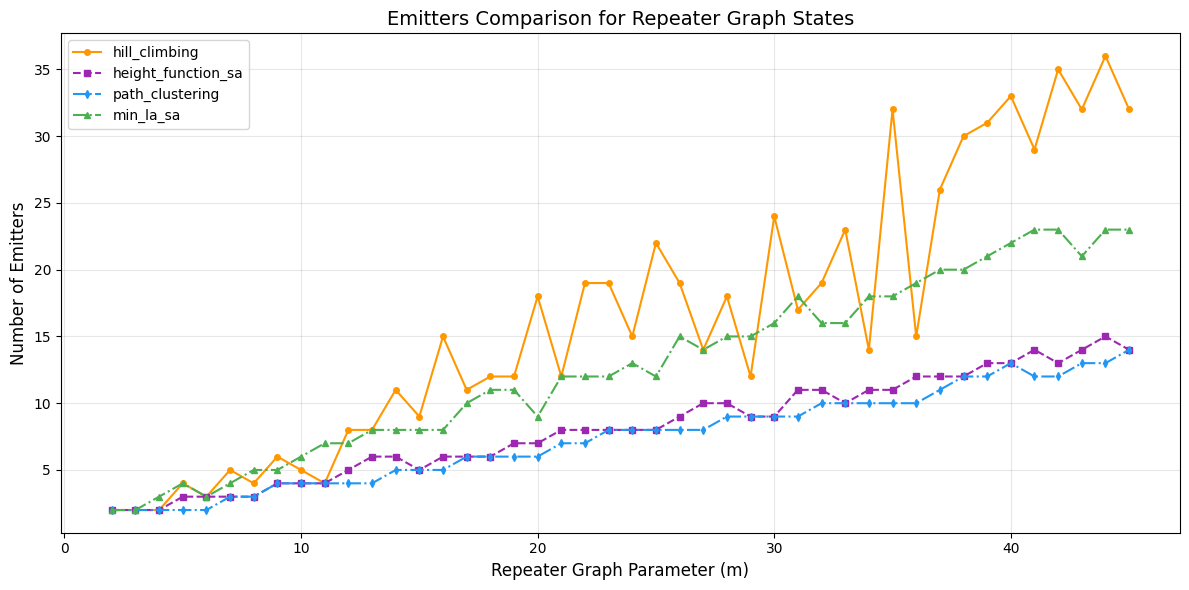

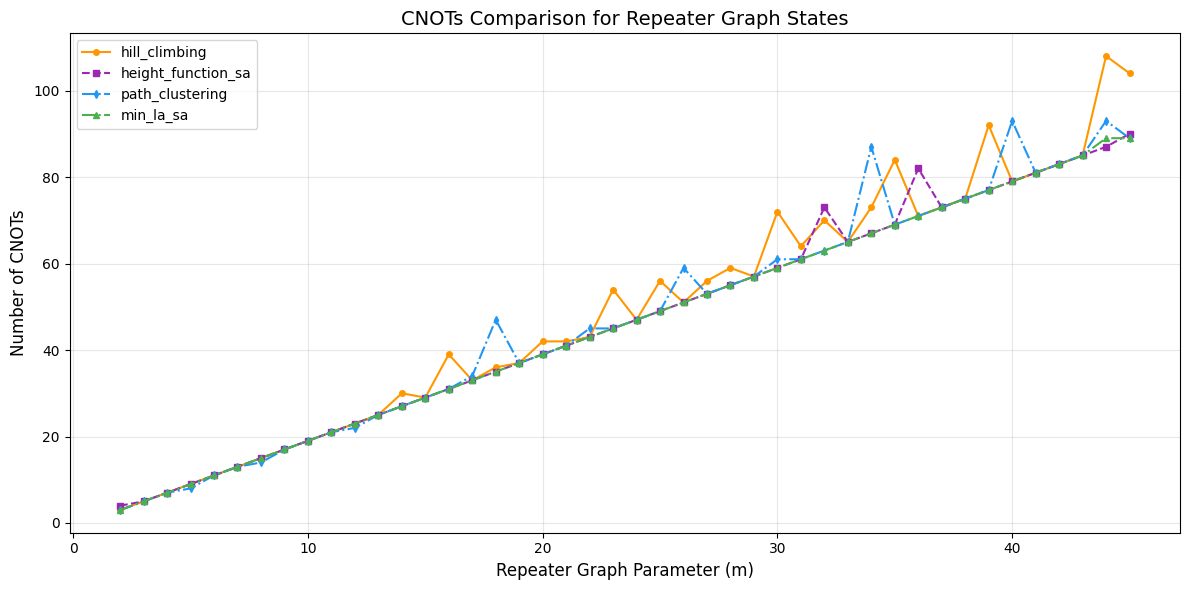

In [7]:
# Load all simulation results
emitters_SAminLA20 = load_simulation_results('SAminLA20', 'emitters')
cnots_SAminLA20 = load_simulation_results('SAminLA20', 'cnots')

emitters_rank_width_sa = load_simulation_results('rank_width_sa', 'emitters')
cnots_rank_width_sa = load_simulation_results('rank_width_sa', 'cnots')

# emitters_rank_width = load_simulation_results('rank_width', 'emitters')
# cnots_rank_width = load_simulation_results('rank_width', 'cnots')

emitters_rank_width = load_simulation_results('rank_width_fix_bug', 'emitters')
cnots_rank_width = load_simulation_results('rank_width_fix_bug', 'cnots')

emitters_path_refined = load_simulation_results('path_refined', 'emitters')
cnots_path_refined = load_simulation_results('path_refined', 'cnots')

# X-axis: parameter values (m = 2 to 45)
m_values = np.arange(2, 2 + len(emitters_SAminLA20))

ALGOS = ["lrw", "lrw_sa", "path_clust", "saminla"]
ALGO_LABELS = {
    "lrw": "hill_climbing",
    "lrw_sa": "height_function_sa",
    "path_clust": "path_clustering",
    "saminla": "min_la_sa",
}
ALGO_COLORS = ["#FF9800", "#9C27B0", "#2196F3", "#4CAF50"]
ALGO_STYLES = {
    "lrw": "o-",
    "lrw_sa": "s--",
    "path_clust": "d-.",
    "saminla": "^-.",
}

RGS_DATA = {
    "lrw": {"emitters": emitters_rank_width, "cnots": cnots_rank_width},
    "lrw_sa": {"emitters": emitters_rank_width_sa, "cnots": cnots_rank_width_sa},
    "path_clust": {"emitters": emitters_path_refined, "cnots": cnots_path_refined},
    "saminla": {"emitters": emitters_SAminLA20, "cnots": cnots_SAminLA20},
}

# --- Plot Emitters ---
fig, ax = plt.subplots(figsize=(12, 6))

for algo, color in zip(ALGOS, ALGO_COLORS):
    ax.plot(
        m_values, RGS_DATA[algo]["emitters"], ALGO_STYLES[algo],
        color=color, label=ALGO_LABELS[algo], markersize=4
    )

ax.set_xlabel('Repeater Graph Parameter (m)', fontsize=12)
ax.set_ylabel('Number of Emitters', fontsize=12)
ax.set_title('Emitters Comparison for Repeater Graph States', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot CNOTs ---
fig, ax = plt.subplots(figsize=(12, 6))

for algo, color in zip(ALGOS, ALGO_COLORS):
    ax.plot(
        m_values, RGS_DATA[algo]["cnots"], ALGO_STYLES[algo],
        color=color, label=ALGO_LABELS[algo], markersize=4
    )

ax.set_xlabel('Repeater Graph Parameter (m)', fontsize=12)
ax.set_ylabel('Number of CNOTs', fontsize=12)
ax.set_title('CNOTs Comparison for Repeater Graph States', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## RHG lattices - creation

In [16]:
import pickle

maximum = 4
repeater_graph_emitters_Dec = []
repeater_graph_cnots_Dec = []

for x in range(1, maximum+1):
    for y in range(x, maximum+1):
        for z in range(y, maximum+1):

            print(f'----------------- START RGH for {x,y,z} -----------------')
            repeater_graph = GraphState(shape='rhg', prms=(x,y,z))

            igraph_repeater = repeater_graph.graph
            G = igraph_repeater.to_networkx()
            
            # --- PICKLING SECTION ---
            # Create a descriptive filename
            filename = f"/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/photonic-graphstate-generator-main/step4_rgh_database/RGH_{x}_{y}_{z}.pkl"
            
            with open(filename, 'wb') as f:
                pickle.dump(G, f)
            
            print(f"Saved: {filename}")
            print(f"Edges {len(G.edges())} | Nodes {len(G.nodes())}")

----------------- START RGH for (1, 1, 1) -----------------
Saved: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/photonic-graphstate-generator-main/step4_rgh_database/RGH_1_1_1.pkl
Edges 24 | Nodes 18
----------------- START RGH for (1, 1, 2) -----------------
Saved: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/photonic-graphstate-generator-main/step4_rgh_database/RGH_1_1_2.pkl
Edges 44 | Nodes 31
----------------- START RGH for (1, 1, 3) -----------------
Saved: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/photonic-graphstate-generator-main/step4_rgh_database/RGH_1_1_3.pkl
Edges 64 | Nodes 44
----------------- START RGH for (1, 1, 4) -----------------
Saved: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/photonic-graphstate-generator-main/step4_rgh_database/RGH_1_1_4.pkl
Edges 84 | Nodes 57
----------------- START RGH for (1, 2, 2) -----------------
Saved: /Users/konstantinosrafailrevis/Deskto